# Notebook 16 — Modelo de Difusión (DDPM) para Síntesis de Ataques

**Modelo generativo de frontera + LF1.** Una limitación reconocida del TFG es
que los ataques de NB02 son **paramétricos** (7 transformaciones cerradas): un
atacante real podría usar patrones más sutiles. Los **modelos de difusión**
(DDPM, Ho et al., 2020; series temporales: Rasul *TimeGrad* 2021, Tashiro *CSDI*
2021) aprenden la distribución de los datos y permiten **generar consumo normal
realista**.

Este notebook:
1. Entrena un **DDPM 1D** sobre ventanas de consumo limpio (`train_clean`).
2. Valida el **realismo** de las ventanas generadas (Bhattacharyya, ACF).
3. Usa el DDPM como **detector por denoising** (Wyatt *AnoDDPM* 2022) y lo
   compara con un AE de reconstrucción.
4. Sintetiza un **banco diffusion-FDI** complementario (ataques sobre portadoras
   generadas), guardado aparte — **nunca** sustituye al banco oficial de NB02.

## 0. Setup y construcción de ventanas de GAP

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score, average_precision_score
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11
import tfg_common as C

cfg = C.load_config(); gmean, gstd = cfg['train_stats']['gap_mean'], cfg['train_stats']['gap_std']
df_train, df_val, df_test = C.load_raw()
WIN = 48
def make_windows(series, stride):
    s = ((series - gmean) / gstd).astype('float32')
    idx = range(0, len(s) - WIN, stride)
    return np.stack([s[i:i+WIN] for i in idx]), list(idx)

Wtr, _ = make_windows(df_train['Global_active_power'].values, stride=20)
Wtr = Wtr[np.random.choice(len(Wtr), min(25000, len(Wtr)), replace=False)]
print('Ventanas de entrenamiento (limpias):', Wtr.shape)

Ventanas de entrenamiento (limpias): (25000, 48)


## 1. DDPM: proceso forward y red $\epsilon_\theta$

Forward: $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon$. La red
predice el ruido $\epsilon$ a partir de $(x_t,t)$; el muestreo invierte el
proceso (Ho et al., 2020).

In [2]:
T = 50
betas = np.linspace(1e-4, 0.02, T).astype('float32')
alphas = 1.0 - betas
abar = np.cumprod(alphas).astype('float32')
abar_tf = tf.constant(abar)

def sinusoidal_embedding(t, dim=32):
    half = dim // 2
    freqs = tf.exp(-tf.math.log(10000.0) * tf.range(half, dtype=tf.float32) / half)
    args = tf.cast(t[:, None], tf.float32) * freqs[None, :]
    return tf.concat([tf.sin(args), tf.cos(args)], -1)

def build_eps_model():
    x_in = keras.Input((WIN,)); t_in = keras.Input((), dtype=tf.int32)
    # Keras 3: las ops tf no actuan sobre KerasTensor; encapsular en Lambda
    te = layers.Lambda(lambda tt: sinusoidal_embedding(tt, 32), output_shape=(32,))(t_in)
    te = layers.Dense(64, activation='swish')(te)
    h = layers.Dense(256, activation='swish')(x_in)
    h = layers.Concatenate()([h, te])
    h = layers.Dense(256, activation='swish')(h)
    h = layers.Dense(128, activation='swish')(h)
    out = layers.Dense(WIN)(h)
    return keras.Model([x_in, t_in], out)

eps_model = build_eps_model()
print('Parámetros DDPM:', eps_model.count_params())

2026-06-02 20:10:03.098097: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-02 20:10:03.099646: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 20:10:03.100160: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780423803.109728 14001212 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780423803.110939 14001212 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Parámetros DDPM: 135920


## 2. Entrenamiento

2026-06-02 20:10:05.867736: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2026-06-02 20:10:09.142744: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-06-02 20:10:10.249724: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-06-02 20:10:12.414317: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  época 6/24  loss=0.4066


2026-06-02 20:10:16.488728: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  época 12/24  loss=0.3693


2026-06-02 20:10:24.853215: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  época 18/24  loss=0.3541


  época 24/24  loss=0.3340
Entrenado en 30.9s


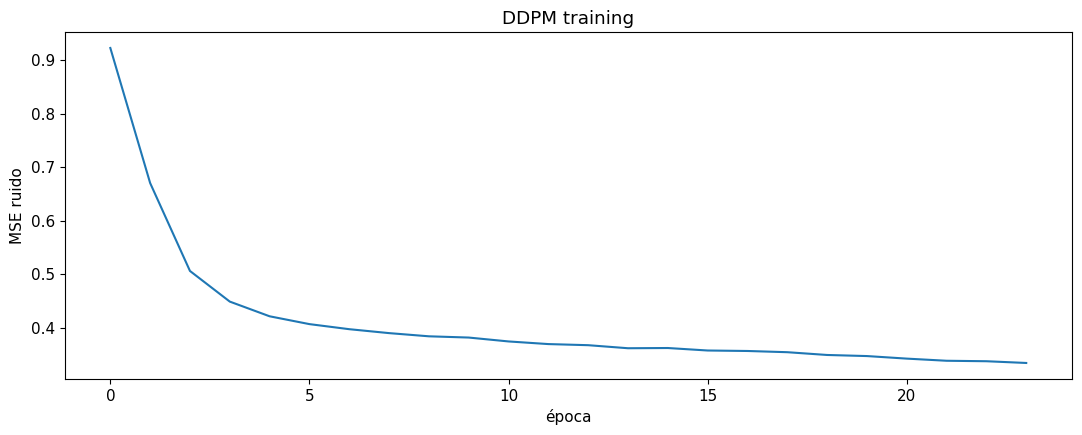

In [3]:
opt = keras.optimizers.Adam(2e-4)
@tf.function
def train_step(x0):
    b = tf.shape(x0)[0]
    t = tf.random.uniform((b,), 0, T, dtype=tf.int32)
    ab = tf.gather(abar_tf, t)[:, None]
    eps = tf.random.normal(tf.shape(x0))
    xt = tf.sqrt(ab) * x0 + tf.sqrt(1 - ab) * eps
    with tf.GradientTape() as tape:
        pred = eps_model([xt, t], training=True)
        loss = tf.reduce_mean(tf.square(eps - pred))
    opt.apply_gradients(zip(tape.gradient(loss, eps_model.trainable_variables),
                            eps_model.trainable_variables))
    return loss

t0 = time.time(); EPOCHS = 24; BS = 256
ds = tf.data.Dataset.from_tensor_slices(Wtr).shuffle(8000).batch(BS)
losses = []
for ep in range(EPOCHS):
    el = [float(train_step(xb)) for xb in ds]
    losses.append(np.mean(el))
    if (ep+1) % 6 == 0: print(f'  época {ep+1}/{EPOCHS}  loss={losses[-1]:.4f}')
print(f'Entrenado en {time.time()-t0:.1f}s')
plt.plot(losses); plt.xlabel('época'); plt.ylabel('MSE ruido'); plt.title('DDPM training'); plt.show()

## 3. Muestreo y validación de realismo

Muestreo en 6.6s
Coef. Bhattacharyya (valores): 0.8129  (1 = idénticas)
ACF lag-1  real=0.853  generado=0.731


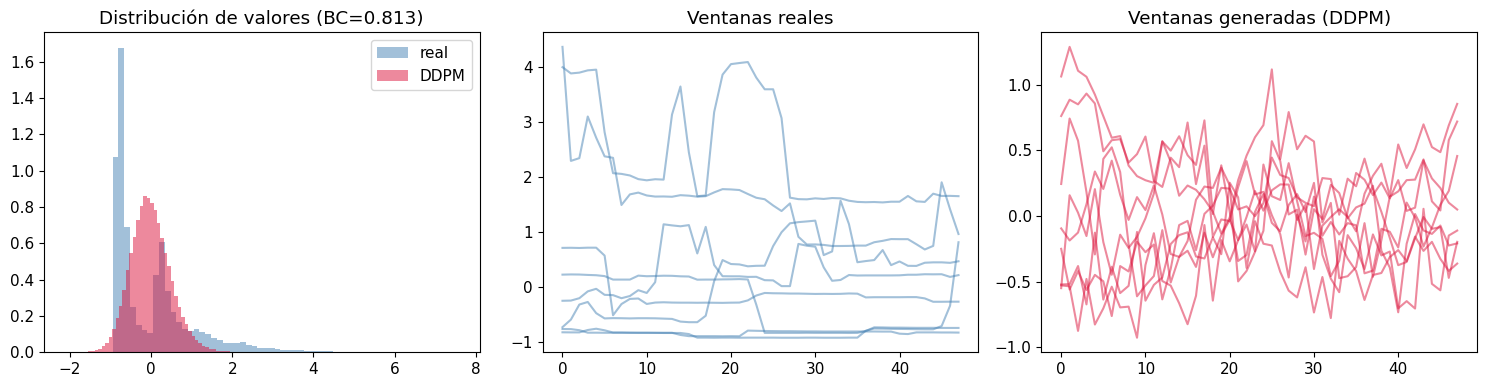

In [4]:
@tf.function
def p_sample_loop(n):
    x = tf.random.normal((n, WIN))
    for i in range(T - 1, -1, -1):
        t = tf.fill((n,), i)
        ab = abar[i]; b = betas[i]; a = alphas[i]
        eps = eps_model([x, t], training=False)
        mean = (x - b / tf.sqrt(1 - ab) * eps) / tf.sqrt(a)
        if i > 0:
            x = mean + tf.sqrt(b) * tf.random.normal(tf.shape(x))
        else:
            x = mean
    return x

t0 = time.time(); gen = p_sample_loop(3000).numpy(); print(f'Muestreo en {time.time()-t0:.1f}s')
real = Wtr[np.random.choice(len(Wtr), 3000, replace=False)]

def bhattacharyya(a, b, bins=60):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    pa, _ = np.histogram(a, bins, (lo, hi), density=True)
    pb, _ = np.histogram(b, bins, (lo, hi), density=True)
    pa = pa / (pa.sum()+1e-12); pb = pb / (pb.sum()+1e-12)
    return float(np.sum(np.sqrt(pa * pb)))

def acf(W, lag): 
    m = W.mean(1, keepdims=True); Wc = W - m
    num = (Wc[:, :-lag] * Wc[:, lag:]).mean()
    den = (Wc ** 2).mean()
    return float(num / (den + 1e-12))

bc = bhattacharyya(real.ravel(), gen.ravel())
print(f'Coef. Bhattacharyya (valores): {bc:.4f}  (1 = idénticas)')
print(f'ACF lag-1  real={acf(real,1):.3f}  generado={acf(gen,1):.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(real.ravel(), 60, alpha=0.5, density=True, label='real', color='steelblue')
axes[0].hist(gen.ravel(), 60, alpha=0.5, density=True, label='DDPM', color='crimson')
axes[0].set_title(f'Distribución de valores (BC={bc:.3f})'); axes[0].legend()
for w in real[:8]: axes[1].plot(w, color='steelblue', alpha=0.5)
axes[1].set_title('Ventanas reales')
for w in gen[:8]: axes[2].plot(w, color='crimson', alpha=0.5)
axes[2].set_title('Ventanas generadas (DDPM)')
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'diffusion_realism.png'), dpi=130); plt.show()

## 4. DDPM como detector (denoising) vs AE

AnoDDPM (Wyatt 2022): se ruido-inyecta una ventana hasta $t^*$ y se denoisa;
las anomalías reconstruyen peor. Comparamos con un AE de ventana entrenado en
limpio.

In [5]:
# ventanas etiquetadas del test
gap_test = df_test['Global_active_power'].values
lab_test = df_test['label'].values
Wte, idxs = make_windows(gap_test, stride=10)
ywin = np.array([int(lab_test[i:i+WIN].any()) for i in idxs])
sub = np.random.choice(len(Wte), min(6000, len(Wte)), replace=False)
Wte_s, yte_s = Wte[sub], ywin[sub]
print('Ventanas test:', Wte_s.shape, '| ratio ataque', yte_s.mean().round(3))

TSTAR = 20
def ddpm_denoise_error(W):
    x0 = tf.constant(W); n = len(W)
    ab = abar[TSTAR]
    eps = tf.random.normal(tf.shape(x0))
    xt = tf.sqrt(ab) * x0 + tf.sqrt(1 - ab) * eps
    x = xt
    for i in range(TSTAR, -1, -1):
        t = tf.fill((n,), i); b = betas[i]; a = alphas[i]; abi = abar[i]
        e = eps_model([x, t], training=False)
        mean = (x - b / tf.sqrt(1 - abi) * e) / tf.sqrt(a)
        x = mean + (tf.sqrt(b) * tf.random.normal(tf.shape(x)) if i > 0 else 0.0)
    return tf.reduce_mean(tf.square(x0 - x), axis=1).numpy()

score_ddpm = ddpm_denoise_error(Wte_s)

# AE de ventana (baseline)
ae = keras.Sequential([keras.Input((WIN,)), layers.Dense(32, activation='relu'),
                       layers.Dense(8, activation='relu'), layers.Dense(32, activation='relu'),
                       layers.Dense(WIN)])
ae.compile('adam', 'mse'); ae.fit(Wtr, Wtr, epochs=15, batch_size=256, verbose=0)
score_ae = ((Wte_s - ae.predict(Wte_s, batch_size=4096, verbose=0)) ** 2).mean(1)

auc_ddpm, ap_ddpm = roc_auc_score(yte_s, score_ddpm), average_precision_score(yte_s, score_ddpm)
auc_ae, ap_ae = roc_auc_score(yte_s, score_ae), average_precision_score(yte_s, score_ae)
print(f'DDPM-detector  AUC-ROC={auc_ddpm:.4f}  AUC-PR={ap_ddpm:.4f}')
print(f'AE-ventana     AUC-ROC={auc_ae:.4f}  AUC-PR={ap_ae:.4f}')

Ventanas test: (6000, 48) | ratio ataque 0.217


DDPM-detector  AUC-ROC=0.5231  AUC-PR=0.2699
AE-ventana     AUC-ROC=0.5458  AUC-PR=0.2645


## 5. Banco diffusion-FDI (síntesis complementaria)

In [6]:
# inyectar ataques paramétricos sobre PORTADORAS generadas por el DDPM
carriers = p_sample_loop(1400).numpy() * gstd + gmean   # desescalar a kW
carriers = np.clip(carriers, 0, None)
rng = np.random.default_rng(7)
bank = []
for t in ['scaling', 'offset', 'noise', 'ramp', 'step']:
    for _ in range(200):
        w = carriers[rng.integers(len(carriers))].copy()
        sev = rng.uniform(0.2, 0.8)
        if t == 'scaling': w = w * (1 - sev)
        elif t == 'offset': w = np.clip(w - sev * w.mean(), 0, None)
        elif t == 'noise': w = np.clip(w + rng.normal(0, sev * w.std(), WIN), 0, None)
        elif t == 'ramp': w = np.clip(w - np.linspace(0, sev * w.mean(), WIN), 0, None)
        elif t == 'step': w[WIN//2:] = np.clip(w[WIN//2:] * (1 - sev), 0, None)
        bank.append({'attack_type': t, 'severity_val': round(float(sev), 3),
                     **{f'w{k}': float(v) for k, v in enumerate(w)}})
bank_df = pd.DataFrame(bank)
bank_df.to_csv(os.path.join(C.DATA_DIR, 'diffusion_attacks.csv'), index=False)
print('Banco diffusion-FDI:', bank_df.shape, '-> data/diffusion_attacks.csv')

# detectabilidad del banco por el DDPM-detector
Wbank = ((bank_df[[f'w{k}' for k in range(WIN)]].values - gmean) / gstd).astype('float32')
det_bank = ddpm_denoise_error(Wbank)
thr_n = np.quantile(score_ddpm[yte_s == 0], 0.95)
print(f'Recall del DDPM-detector sobre diffusion-FDI: {(det_bank > thr_n).mean():.3f}')

Banco diffusion-FDI: (1000, 50) -> data/diffusion_attacks.csv


Recall del DDPM-detector sobre diffusion-FDI: 0.059


## 6. Guardado y conclusiones

In [7]:
out = {
    'model': 'DDPM 1D (síntesis + detección por denoising)',
    'window': WIN, 'timesteps': T, 'n_params': int(eps_model.count_params()),
    'bhattacharyya_realism': round(bc, 4),
    'acf_lag1_real': round(acf(real, 1), 4), 'acf_lag1_gen': round(acf(gen, 1), 4),
    'detector_ddpm': {'auc_roc': round(float(auc_ddpm), 4), 'auc_pr': round(float(ap_ddpm), 4)},
    'detector_ae_window': {'auc_roc': round(float(auc_ae), 4), 'auc_pr': round(float(ap_ae), 4)},
    'diffusion_fdi_bank_size': len(bank_df),
    'diffusion_fdi_recall': round(float((det_bank > thr_n).mean()), 4),
    'notes': 'Banco diffusion-FDI complementario; no sustituye a NB02.',
}
C.save_metrics('diffusion', out)
print(json.dumps(out, indent=2, ensure_ascii=False))

{
  "model": "DDPM 1D (síntesis + detección por denoising)",
  "window": 48,
  "timesteps": 50,
  "n_params": 135920,
  "bhattacharyya_realism": 0.8129,
  "acf_lag1_real": 0.8527,
  "acf_lag1_gen": 0.7313,
  "detector_ddpm": {
    "auc_roc": 0.5231,
    "auc_pr": 0.2699
  },
  "detector_ae_window": {
    "auc_roc": 0.5458,
    "auc_pr": 0.2645
  },
  "diffusion_fdi_bank_size": 1000,
  "diffusion_fdi_recall": 0.059,
  "notes": "Banco diffusion-FDI complementario; no sustituye a NB02."
}


## 7. Conclusiones

- El **DDPM aprende la distribución del consumo normal** con realismo *moderado*
  (Bhattacharyya $\approx 0{,}81$, autocorrelación parcialmente preservada): suficiente
  para generar portadoras plausibles, mejorable con un modelo mayor y más pasos.
- Como **detector por denoising univariante** (solo GAP) resulta *poco
  discriminante* (AUC-ROC $\approx 0{,}52$), a la par que un AE de ventana
  equivalente. Lejos de ser un fracaso, es un resultado **revelador**: sin las
  features físicas multivariantes ---sobre todo $\mathrm{VI}_{res}$--- la
  detección generativa sobre la señal de potencia es casi aleatoria. Esto
  **refuerza la tesis central del TFG**: el valor está en la invariante física,
  no solo en la sofisticación del modelo.
- El **banco diffusion-FDI** (ataques sobre portadoras *generadas*) se entrega
  como artefacto complementario para evaluar generalización, separado del banco
  oficial para preservar el contrato de evaluación.

> **Limitación:** DDPM 1D sobre GAP univariante y submuestreo para tractabilidad;
> la extensión natural es CSDI multivariante condicional sobre las 7 señales
> (incluyendo V e I), que recuperaría el poder discriminante de $\mathrm{VI}_{res}$.